# Defense Metrics Comparison

Graphical analysis for defended retraining outputs such as Isolation Forest, GMM, OPTICS, MDR-inspired filtering, and oracle sanity checks. The default focus is EMBER2018 Isolation Forest because that is the newest batch of defense runs.

In [1]:
from pathlib import Path
import json
import os

import numpy as np
import pandas as pd

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_ROOT = PROJECT_ROOT / "results"
print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULTS_ROOT:", RESULTS_ROOT)

PROJECT_ROOT: /Users/falcon/Machine Learning/Defense GMM-Maha
RESULTS_ROOT: /Users/falcon/Machine Learning/Defense GMM-Maha/results


## Load Defense Metrics

`run_defense_retrain` writes `defense_retrain_metrics.csv`. This loader parses the surrounding artifact path so each row knows its dataset, sampling strategy, feature/value selector, target feature group, and defense method.

In [2]:
def parse_experiment_dir(dirname: str) -> dict:
    parts = dirname.split("__")
    if len(parts) < 5:
        return {
            "dataset_id": None,
            "model_name": None,
            "feature_selector": None,
            "value_selector": None,
            "target_features": None,
        }
    return {
        "dataset_id": parts[0],
        "model_name": parts[1],
        "feature_selector": parts[2],
        "value_selector": parts[3],
        "target_features": parts[4],
    }


def dataset_and_sampling_from_parts(parts: list[str]) -> tuple[str, str]:
    if "results" not in parts:
        return "unknown", "unknown"
    start = parts.index("results") + 1
    after = parts[start:]
    if len(after) >= 3 and after[0] == "ember" and after[1] == "20%":
        sampling = after[2]
        return "EMBER2018", sampling.removesuffix("-defense")
    if len(after) >= 3 and after[0] == "ember2024":
        platform = after[1]
        sampling = after[2]
        return f"EMBER2024 {platform.capitalize()}", sampling.removesuffix("-defense")
    return "unknown", "unknown"


def parse_defense_path(parts_between_artifact_and_retrain: list[str], retrain_mode: str) -> dict:
    if retrain_mode == "oracle_poisoned_retrain":
        return {
            "defense_family": "oracle",
            "defense_method": "oracle_poisoned",
            "defense_setting": "oracle_poisoned",
        }
    if not parts_between_artifact_and_retrain:
        return {
            "defense_family": "direct_indices",
            "defense_method": "provided_indices",
            "defense_setting": "artifact_root",
        }

    head = parts_between_artifact_and_retrain[0]
    if head == "severi_detectors":
        setting = parts_between_artifact_and_retrain[1] if len(parts_between_artifact_and_retrain) > 1 else "unknown"
        if setting.startswith("isolation_forest"):
            method = "isolation_forest"
        elif setting.startswith("spectral_signature"):
            method = "spectral_signature"
        else:
            method = setting.split("_")[0]
        return {"defense_family": head, "defense_method": method, "defense_setting": setting}
    if head == "defense_preprocessing" and "gmm_defense" in parts_between_artifact_and_retrain:
        gmm_idx = parts_between_artifact_and_retrain.index("gmm_defense")
        setting = parts_between_artifact_and_retrain[gmm_idx + 1] if len(parts_between_artifact_and_retrain) > gmm_idx + 1 else "unknown"
        return {"defense_family": "gmm_defense", "defense_method": "gmm_mahalanobis", "defense_setting": setting}
    if head == "optics_iterative":
        setting = parts_between_artifact_and_retrain[1] if len(parts_between_artifact_and_retrain) > 1 else "unknown"
        return {"defense_family": head, "defense_method": "optics_iterative", "defense_setting": setting}
    if head == "mdr_inspired":
        return {"defense_family": head, "defense_method": "mdr_inspired", "defense_setting": "mdr_inspired"}
    return {"defense_family": head, "defense_method": head, "defense_setting": "/".join(parts_between_artifact_and_retrain)}


def load_json_if_exists(path: Path):
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def parse_metric_path(path: Path) -> dict:
    rel = path.relative_to(PROJECT_ROOT)
    parts = list(rel.parts)
    dataset_label, sampling_strategy = dataset_and_sampling_from_parts(parts)
    artifact_idx = parts.index("attack_artifacts")
    experiment_dir = parts[artifact_idx + 1]
    retrain_mode = parts[-2]
    between = parts[artifact_idx + 2 : -2]
    parsed = parse_experiment_dir(experiment_dir)
    defense = parse_defense_path(between, retrain_mode)

    artifact_dir = PROJECT_ROOT.joinpath(*parts[: artifact_idx + 2])
    detector_dir = path.parent.parent if path.parent.name in {"defended_retrain", "oracle_poisoned_retrain"} else path.parent
    detector_meta = load_json_if_exists(detector_dir / "severi_detector_metadata.json")
    detector_config = (detector_meta or {}).get("config", {})

    return {
        "dataset_label": dataset_label,
        "sampling_strategy": sampling_strategy,
        "experiment_dir": experiment_dir,
        "artifact_dir": str(artifact_dir),
        "retrain_mode": retrain_mode,
        "metrics_path": str(path),
        **parsed,
        **defense,
        "detector_feature_mode": detector_config.get("feature_mode"),
        "detector_top_k": detector_config.get("top_k"),
        "detector_contamination": detector_config.get("contamination"),
        "detector_max_benign_rows": detector_config.get("max_benign_rows"),
    }


def load_defense_metrics() -> pd.DataFrame:
    rows = []
    for path in sorted(RESULTS_ROOT.glob("**/defense_retrain_metrics.csv")):
        df = pd.read_csv(path)
        if df.empty:
            continue
        row = df.iloc[0].to_dict()
        row.update(parse_metric_path(path))
        rows.append(row)
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    out["selector_pair"] = out["feature_selector"].fillna("?") + " + " + out["value_selector"].fillna("?")
    out["defense_label"] = out["defense_method"] + " / " + out["defense_setting"]
    out["backdoored_asr_percent"] = out["backdoored_asr"] * 100
    out["defended_asr_percent"] = out["defended_asr"] * 100
    out["asr_reduction_pp"] = (out["backdoored_asr"] - out["defended_asr"]) * 100
    out["backdoored_clean_accuracy_percent"] = out["backdoored_clean_accuracy"] * 100
    out["defended_clean_accuracy_percent"] = out["defended_clean_accuracy"] * 100
    out["clean_accuracy_delta_pp"] = (out["defended_clean_accuracy"] - out["backdoored_clean_accuracy"]) * 100
    out["poison_recall_percent"] = out["poison_recall"] * 100
    out["clean_false_positive_rate_percent"] = out["clean_false_positive_rate"] * 100
    out["removed_row_percent"] = out["removed_rows"] / out["train_rows_before"] * 100
    out["poison_removal_precision_percent"] = np.where(
        out["removed_rows"] > 0,
        out["removed_poisoned_rows"] / out["removed_rows"] * 100,
        np.nan,
    )
    return out


defense_df = load_defense_metrics()
print("Loaded defense metric rows:", len(defense_df))
display(defense_df.head())

Loaded defense metric rows: 25


,train_rows_before,train_rows_after,removed_rows,total_poisoned_rows,total_clean_rows,removed_poisoned_rows,removed_clean_rows,poison_recall,clean_false_positive_rate,watermarked_malware_eval_rows,defended_watermarked_malware_detection_rate,defended_asr,defended_clean_accuracy,backdoored_watermarked_malware_detection_rate,backdoored_asr,backdoored_clean_accuracy,dataset_label,sampling_strategy,experiment_dir,artifact_dir,retrain_mode,metrics_path,dataset_id,model_name,feature_selector,value_selector,target_features,defense_family,defense_method,defense_setting,detector_feature_mode,detector_top_k,detector_contamination,detector_max_benign_rows,selector_pair,defense_label,backdoored_asr_percent,defended_asr_percent,asr_reduction_pp,backdoored_clean_accuracy_percent,defended_clean_accuracy_percent,clean_accuracy_delta_pp,poison_recall_percent,clean_false_positive_rate_percent,removed_row_percent,poison_removal_precision_percent
0,120000.0,119172.0,828.0,600.0,119400.0,5.0,823.0,0.008333,0.006893,97313.0,0.779803,0.220197,0.898380,0.783677,0.216323,0.89413,EMBER2018,random,ember__lightgbm__combined_shap__combined_shap_...,/Users/falcon/Machine Learning/Defense GMM-Mah...,defended_retrain,/Users/falcon/Machine Learning/Defense GMM-Mah...,ember,lightgbm,combined_shap,combined_shap,problem_space_conservative,gmm_defense,gmm_mahalanobis,cov_diag_k1-10_reg1em06_remove1p,None,NaN,NaN,None,combined_shap + combined_shap,gmm_mahalanobis / cov_diag_k1-10_reg1em06_remo...,21.632259,22.019668,-0.387410,89.413,89.8380,0.4250,0.833333,0.689280,0.690000,0.603865
1,120000.0,119400.0,600.0,600.0,119400.0,600.0,0.0,1.000000,0.000000,97313.0,0.786339,0.213661,0.873380,0.783677,0.216323,0.89413,EMBER2018,random,ember__lightgbm__combined_shap__combined_shap_...,/Users/falcon/Machine Learning/Defense GMM-Mah...,oracle_poisoned_retrain,/Users/falcon/Machine Learning/Defense GMM-Mah...,ember,lightgbm,combined_shap,combined_shap,problem_space_conservative,oracle,oracle_poisoned,oracle_poisoned,None,NaN,NaN,None,combined_shap + combined_shap,oracle_poisoned / oracle_poisoned,21.632259,21.366107,0.266151,89.413,87.3380,-2.0750,100.000000,0.000000,0.500000,100.000000
2,120000.0,95187.0,24813.0,600.0,119400.0,196.0,24617.0,0.326667,0.206173,97313.0,0.865979,0.134021,0.891315,0.783677,0.216323,0.89413,EMBER2018,random,ember__lightgbm__combined_shap__combined_shap_...,/Users/falcon/Machine Learning/Defense GMM-Mah...,defended_retrain,/Users/falcon/Machine Learning/Defense GMM-Mah...,ember,lightgbm,combined_shap,combined_shap,problem_space_conservative,gmm_defense,gmm_mahalanobis,cov_diag_k1-10_reg1em06_remove30p,None,NaN,NaN,None,combined_shap + combined_shap,gmm_mahalanobis / cov_diag_k1-10_reg1em06_remo...,21.632259,13.402115,8.230144,89.413,89.1315,-0.2815,32.666667,20.617253,20.677500,0.789909
3,120000.0,119997.0,3.0,600.0,119400.0,0.0,3.0,0.000000,0.000025,97313.0,0.803397,0.196603,0.891630,0.783677,0.216323,0.89413,EMBER2018,random,ember__lightgbm__combined_shap__combined_shap_...,/Users/falcon/Machine Learning/Defense GMM-Mah...,defended_retrain,/Users/falcon/Machine Learning/Defense GMM-Mah...,ember,lightgbm,combined_shap,combined_shap,problem_space_conservative,mdr_inspired,mdr_inspired,mdr_inspired,None,NaN,NaN,None,combined_shap + combined_shap,mdr_inspired / mdr_inspired,21.632259,19.660271,1.971987,89.413,89.1630,-0.2500,0.000000,0.002513,0.002500,0.000000
4,120000.0,100945.0,19055.0,600.0,119400.0,20.0,19035.0,0.033333,0.159422,97313.0,0.796060,0.203940,0.882650,0.783677,0.216323,0.89413,EMBER2018,random,ember__lightgbm__combined_shap__combined_shap_...,/Users/falcon/Machine Learning/Defense GMM-Mah...,defended_retrain,/Users/falcon/Machine Learning/Defense GMM-Mah...,ember,lightgbm,combined_shap,combined_shap,problem_space_conservative,optics_iterative,optics_iterative,all_top16_fixed_or_delta_clean80p_w5p,None,NaN,NaN,None,combined_shap + combined_shap,optics_iterative / all_top16_fixed_or_delta_cl...,21.632259,20.393986,1.238272,89.413,88.2650

## Coverage

In [3]:
if defense_df.empty:
    raise RuntimeError("No defense_retrain_metrics.csv files found under results/.")

coverage = (
    defense_df
    .groupby(["dataset_label", "sampling_strategy", "defense_method", "defense_setting", "retrain_mode"], dropna=False)
    .size()
    .rename("runs")
    .reset_index()
    .sort_values(["dataset_label", "sampling_strategy", "defense_method", "defense_setting"])
)
display(coverage)

selector_coverage = (
    defense_df
    .groupby(["dataset_label", "sampling_strategy", "value_selector", "defense_method"], dropna=False)
    .size()
    .rename("runs")
    .reset_index()
    .sort_values(["dataset_label", "sampling_strategy", "value_selector", "defense_method"])
)
display(selector_coverage)

,dataset_label,sampling_strategy,defense_method,defense_setting,retrain_mode,runs
0,EMBER2018,random,gmm_mahalanobis,cov_diag_k1-10_reg1em06_remove1p,defended_retrain,3
1,EMBER2018,random,gmm_mahalanobis,cov_diag_k1-10_reg1em06_remove30p,defended_retrain,3
2,EMBER2018,random,isolation_forest,isolation_forest_hybrid_top32_scaled_contam0p005,defended_retrain,11
3,EMBER2018,random,mdr_inspired,mdr_inspired,defended_retrain,1
4,EMBER2018,random,optics_iterative,all_top16_fixed_or_delta_clean80p_w5p,defended_retrain,3
5,EMBER2018,random,oracle_poisoned,oracle_poisoned,oracle_poisoned_retrain,3
6,EMBER2018,random,provided_indices,artifact_root,defended_retrain,1


,dataset_label,sampling_strategy,value_selector,defense_method,runs
0,EMBER2018,random,argmin_Nv_sum_abs_shap,gmm_mahalanobis,2
1,EMBER2018,random,argmin_Nv_sum_abs_shap,isolation_forest,1
2,EMBER2018,random,argmin_Nv_sum_abs_shap,optics_iterative,1
3,EMBER2018,random,argmin_Nv_sum_abs_shap,oracle_poisoned,1
4,EMBER2018,random,benign_prototype,isolation_forest,1
5,EMBER2018,random,combined_shap,gmm_mahalanobis,2
6,EMBER2018,random,combined_shap,isolation_forest,1
7,EMBER2018,random,combined_shap,mdr_inspired,1
8,EMBER2018,random,combined_shap,optics_iterative,1
9,EMBER2018,random,combined_shap,oracle_poisoned,1


## Focus: EMBER2018 Isolation Forest

In [4]:
FOCUS_DATASET = "EMBER2018"
FOCUS_DEFENSE_METHOD = "isolation_forest"
FOCUS_RETRAIN_MODE = "defended_retrain"

focus_df = defense_df[
    (defense_df["dataset_label"] == FOCUS_DATASET)
    & (defense_df["defense_method"] == FOCUS_DEFENSE_METHOD)
    & (defense_df["retrain_mode"] == FOCUS_RETRAIN_MODE)
    & (defense_df["detector_max_benign_rows"].isna())
].copy()

focus_cols = [
    "dataset_label",
    "sampling_strategy",
    "selector_pair",
    "defense_setting",
    "backdoored_asr_percent",
    "defended_asr_percent",
    "asr_reduction_pp",
    "backdoored_clean_accuracy_percent",
    "defended_clean_accuracy_percent",
    "clean_accuracy_delta_pp",
    "poison_recall_percent",
    "poison_removal_precision_percent",
    "clean_false_positive_rate_percent",
    "removed_row_percent",
    "removed_poisoned_rows",
    "removed_clean_rows",
]

print("Focus rows:", len(focus_df))
display(
    focus_df[focus_cols]
    .sort_values(["sampling_strategy", "backdoored_asr_percent"], ascending=[True, False])
    .round(3)
)

Focus rows: 11


,dataset_label,sampling_strategy,selector_pair,defense_setting,backdoored_asr_percent,defended_asr_percent,asr_reduction_pp,backdoored_clean_accuracy_percent,defended_clean_accuracy_percent,clean_accuracy_delta_pp,poison_recall_percent,poison_removal_precision_percent,clean_false_positive_rate_percent,removed_row_percent,removed_poisoned_rows,removed_clean_rows
15,EMBER2018,random,shap_largest_abs + low_shap_signed,isolation_forest_hybrid_top32_scaled_contam0p005,95.600,89.599,6.001,88.706,87.594,-1.112,68.833,100.000,0.000,0.344,413.0,0.0
21,EMBER2018,random,shap_largest_abs + min_population_new,isolation_forest_hybrid_top32_scaled_contam0p005,95.181,78.454,16.726,88.658,87.830,-0.828,69.000,100.000,0.000,0.345,414.0,0.0
24,EMBER2018,random,shap_largest_abs + quantile_95,isolation_forest_hybrid_top32_scaled_contam0p005,85.015,81.474,3.541,89.886,87.932,-1.953,4.000,5.797,0.327,0.345,24.0,390.0
14,EMBER2018,random,shap_largest_abs + frequency_bounded_signed_shap,isolation_forest_hybrid_top32_scaled_contam0p005,83.195,56.134,27.061,87.740,87.267,-0.473,58.500,84.783,0.053,0.345,351.0,63.0
10,EMBER2018,random,shap_largest_abs + argmin_Nv_sum_abs_shap,isolation_forest_hybrid_top32_scaled_contam0p005,82.150,76.719,5.431,89.430,88.904,-0.526,69.000,100.000,0.000,0.345,414.0,0.0
13,EMBER2018,random,shap_largest_abs + frequency_bounded,isolation_forest_hybrid_top32_scaled_contam0p005,77.596,67.973,9.623,90.056,87.885,-2.171,64.167,92.995,0.024,0.345,385.0,29.0
22,EMBER2018,random,shap_largest_abs + quantile_05,isolation_forest_hybrid_top32_scaled_contam0p005,75.356,73.160,2.196,89.188,87.766,-1.422,0.000,0.000,0.347,0.345,0.0,414.0
12,EMBER2018,random,shap_largest_abs + corr_count_abs_shap,isolation_forest_hybrid_top32_scaled_contam0p005,34.842,27.730,7.112,88.184,90.348,2.164,0.667,0.966,0.343,0.345,4.0,410.0
23,EMBER2018,random,shap_largest_abs + quantile_50,isolation_forest_hybrid_top32_scaled_contam0p005,27.428,24.956,2.472,87.202,88.586,1.383,0.000,0.000,0.347,0.345,0.0,414.0
11,EMBER2018,random,shap_largest_abs + benign_prototype,isolation_forest_hybrid_top32_scaled_contam0p005,25.923,25.230,0.693,88.062,88.820,0.758,0.000,0.000,0.347,0.345,0.0,414.0


## Plot Helpers

In [5]:
MPLCONFIGDIR = PROJECT_ROOT / "build" / "matplotlib"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

SAMPLING_ORDER = [
    "random",
    "cosine_similarity",
    "feature_based_distance",
    "distribution_based_distance",
    "score_wasserstein_distance",
    "score_kde_density_ratio",
    "shap_contribution_distance",
    "mahalanobis_distance",
    "jaccard_distance",
    "wasserstein_distance",
]

VALUE_ORDER = [
    "combined_shap",
    "argmin_Nv_sum_abs_shap",
    "min_population_new",
    "low_shap_signed",
    "frequency_bounded",
    "frequency_bounded_signed_shap",
    "freq_0p1_1p",
    "freq_0p1_5p",
    "freq_0p5_5p",
    "freq_1p_10p",
    "quantile_05",
    "quantile_10",
    "quantile_25",
    "quantile_50",
    "quantile_75",
    "quantile_90",
    "quantile_95",
    "benign_prototype",
    "corr_count_abs_shap",
]

VALUE_LABELS = {
    "combined_shap": "CombinedSHAP",
    "argmin_Nv_sum_abs_shap": "CountAbsSHAP",
    "min_population_new": "MinPopulation",
    "low_shap_signed": "LowSignedSHAP",
    "frequency_bounded": "FreqBounded",
    "frequency_bounded_signed_shap": "FreqSignedSHAP",
    "freq_0p1_1p": "Freq 0.1-1%",
    "freq_0p1_5p": "Freq 0.1-5%",
    "freq_0p5_5p": "Freq 0.5-5%",
    "freq_1p_10p": "Freq 1-10%",
    "quantile_05": "Q05",
    "quantile_10": "Q10",
    "quantile_25": "Q25",
    "quantile_50": "Q50",
    "quantile_75": "Q75",
    "quantile_90": "Q90",
    "quantile_95": "Q95",
    "benign_prototype": "BenignProto",
    "corr_count_abs_shap": "CorrCountAbs",
}


def add_selector_labels(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["value_selector"] = pd.Categorical(out["value_selector"], categories=VALUE_ORDER, ordered=True)
    out["sampling_strategy"] = pd.Categorical(out["sampling_strategy"], categories=SAMPLING_ORDER, ordered=True)
    out["selector_label"] = out["value_selector"].astype(str).map(VALUE_LABELS).fillna(out["value_selector"].astype(str))
    return out


def metric_heatmap(df: pd.DataFrame, metric: str, title: str, *, cmap="viridis", fmt=".1f", center=None, vmin=None, vmax=None, aggfunc="mean"):
    if df.empty:
        print("No rows for", title)
        return
    d = add_selector_labels(df)
    pivot = d.pivot_table(
        index="sampling_strategy",
        columns="value_selector",
        values=metric,
        aggfunc=aggfunc,
        observed=True,
    ).reindex(index=SAMPLING_ORDER, columns=VALUE_ORDER)
    pivot = pivot.rename(columns=VALUE_LABELS)
    pivot = pivot.dropna(how="all", axis=0).dropna(how="all", axis=1)
    if pivot.empty:
        print("Empty pivot for", title)
        return
    fig_width = max(11, 0.75 * pivot.shape[1])
    fig_height = max(3.6, 0.55 * pivot.shape[0] + 1.6)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        center=center,
        vmin=vmin,
        vmax=vmax,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": title},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Value selector")
    ax.set_ylabel("Sampling strategy")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

## Isolation Forest Heatmaps

Positive `ASR reduction` means the defense reduced attack success. Negative `clean accuracy delta` means clean accuracy dropped after defense.

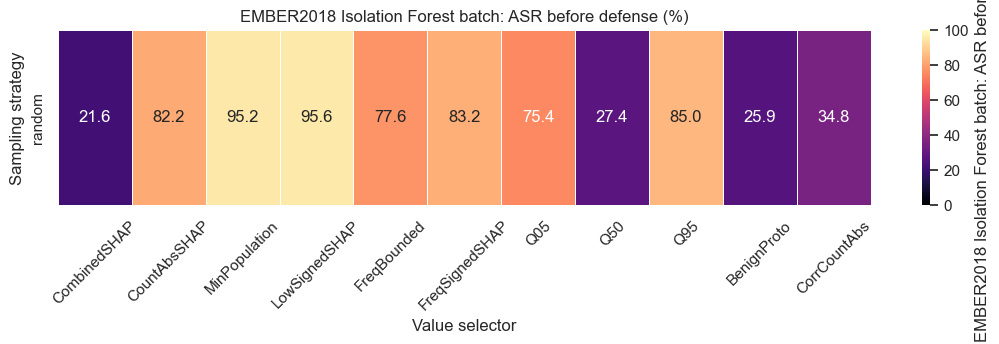

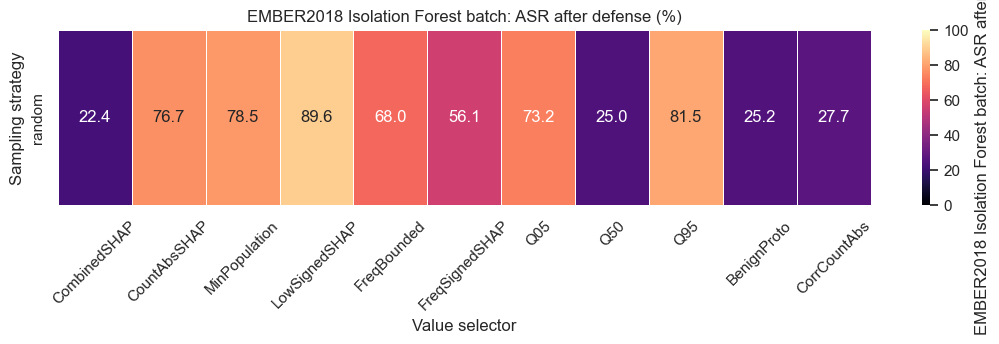

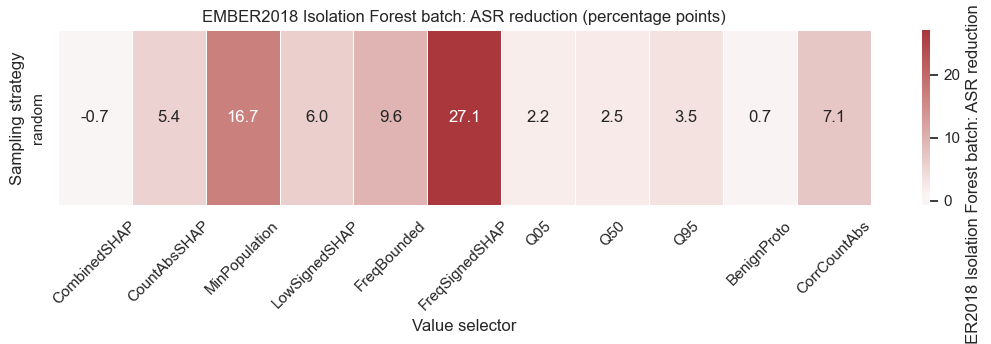

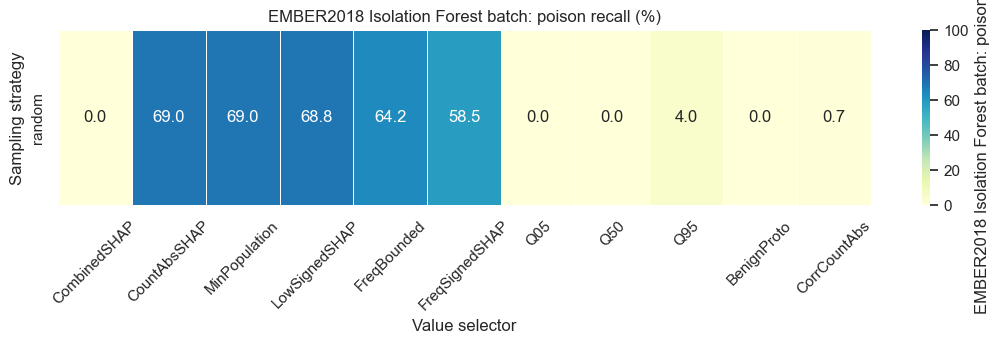

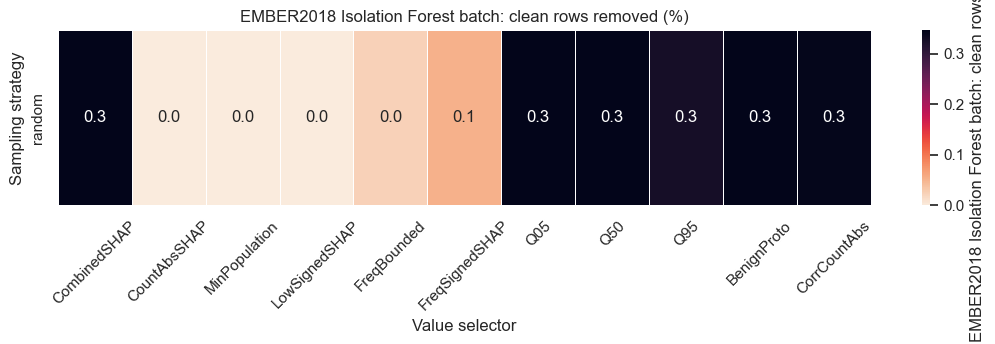

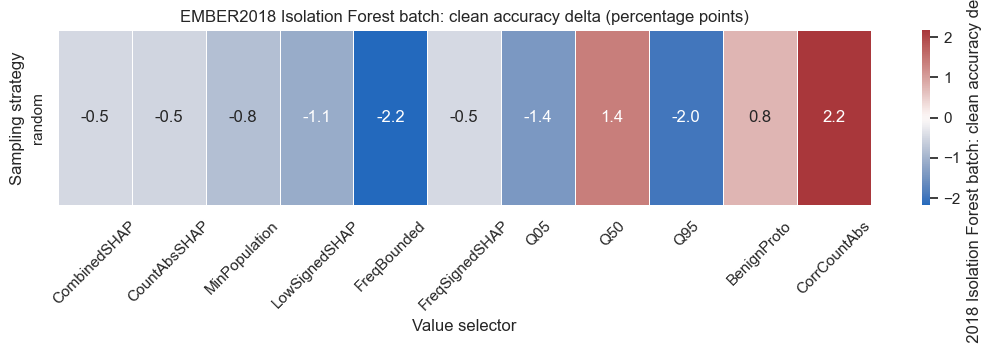

In [6]:
metric_heatmap(
    focus_df,
    "backdoored_asr_percent",
    "EMBER2018 Isolation Forest batch: ASR before defense (%)",
    cmap="magma",
    vmin=0,
    vmax=100,
)
metric_heatmap(
    focus_df,
    "defended_asr_percent",
    "EMBER2018 Isolation Forest batch: ASR after defense (%)",
    cmap="magma",
    vmin=0,
    vmax=100,
)
metric_heatmap(
    focus_df,
    "asr_reduction_pp",
    "EMBER2018 Isolation Forest batch: ASR reduction (percentage points)",
    cmap="vlag",
    center=0,
)
metric_heatmap(
    focus_df,
    "poison_recall_percent",
    "EMBER2018 Isolation Forest batch: poison recall (%)",
    cmap="YlGnBu",
    vmin=0,
    vmax=100,
)
metric_heatmap(
    focus_df,
    "clean_false_positive_rate_percent",
    "EMBER2018 Isolation Forest batch: clean rows removed (%)",
    cmap="rocket_r",
    vmin=0,
)
metric_heatmap(
    focus_df,
    "clean_accuracy_delta_pp",
    "EMBER2018 Isolation Forest batch: clean accuracy delta (percentage points)",
    cmap="vlag",
    center=0,
)

## Isolation Forest Bar And Tradeoff Views

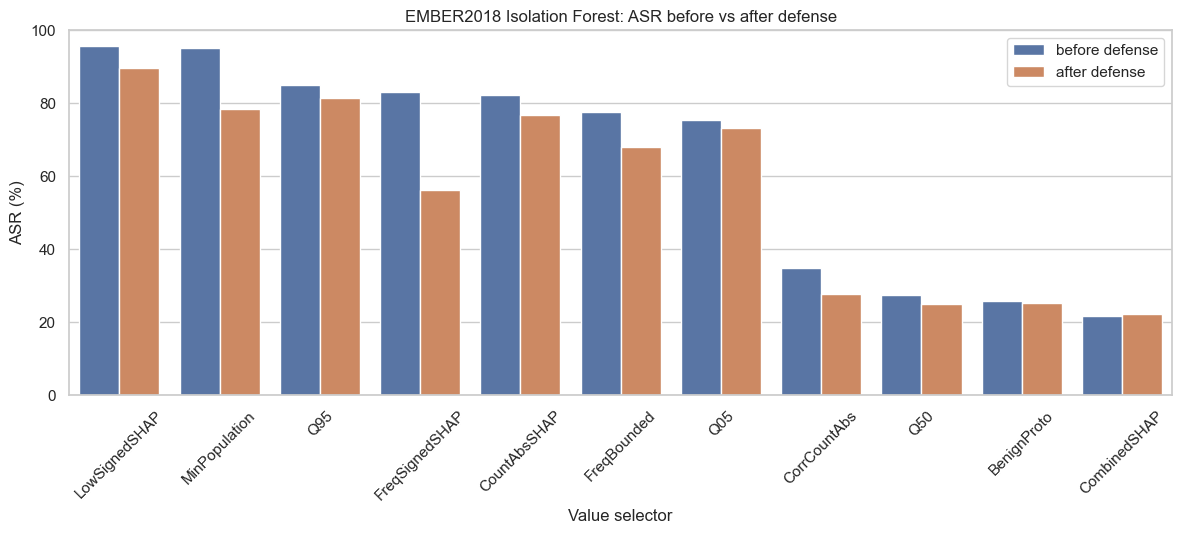

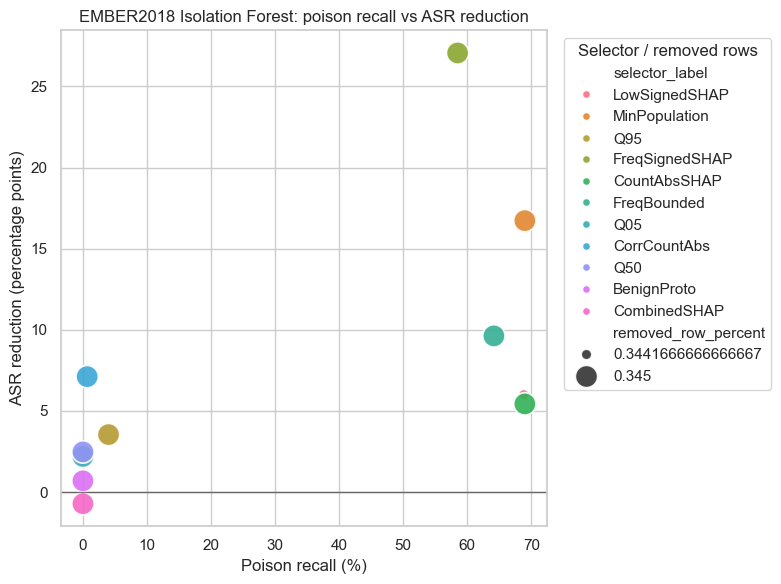

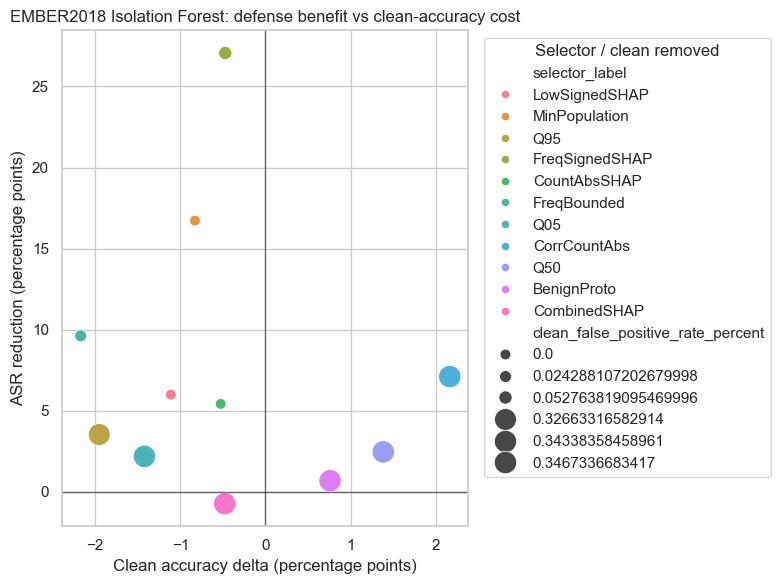

In [7]:
plot_focus = add_selector_labels(focus_df).sort_values("backdoored_asr_percent", ascending=False)

if plot_focus.empty:
    print("No focus rows available.")
else:
    asr_long = plot_focus.melt(
        id_vars=["selector_label", "sampling_strategy"],
        value_vars=["backdoored_asr_percent", "defended_asr_percent"],
        var_name="stage",
        value_name="asr_percent",
    )
    asr_long["stage"] = asr_long["stage"].map({
        "backdoored_asr_percent": "before defense",
        "defended_asr_percent": "after defense",
    })
    fig, ax = plt.subplots(figsize=(12, 5.5))
    sns.barplot(data=asr_long, x="selector_label", y="asr_percent", hue="stage", ax=ax)
    ax.set_title("EMBER2018 Isolation Forest: ASR before vs after defense")
    ax.set_xlabel("Value selector")
    ax.set_ylabel("ASR (%)")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(
        data=plot_focus,
        x="poison_recall_percent",
        y="asr_reduction_pp",
        size="removed_row_percent",
        hue="selector_label",
        sizes=(60, 260),
        alpha=0.9,
        ax=ax,
    )
    ax.axhline(0, color="black", linewidth=1, alpha=0.5)
    ax.set_title("EMBER2018 Isolation Forest: poison recall vs ASR reduction")
    ax.set_xlabel("Poison recall (%)")
    ax.set_ylabel("ASR reduction (percentage points)")
    ax.legend(title="Selector / removed rows", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(
        data=plot_focus,
        x="clean_accuracy_delta_pp",
        y="asr_reduction_pp",
        size="clean_false_positive_rate_percent",
        hue="selector_label",
        sizes=(60, 260),
        alpha=0.9,
        ax=ax,
    )
    ax.axhline(0, color="black", linewidth=1, alpha=0.5)
    ax.axvline(0, color="black", linewidth=1, alpha=0.5)
    ax.set_title("EMBER2018 Isolation Forest: defense benefit vs clean-accuracy cost")
    ax.set_xlabel("Clean accuracy delta (percentage points)")
    ax.set_ylabel("ASR reduction (percentage points)")
    ax.legend(title="Selector / clean removed", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## All Defense Methods Overview

This section is broader than the Isolation Forest batch. It helps compare any GMM, OPTICS, MDR-inspired, Isolation Forest, Spectral Signature, direct-index, and oracle retraining results currently present under `results/`.

,dataset_label,sampling_strategy,selector_pair,defense_method,defense_setting,backdoored_asr_percent,defended_asr_percent,asr_reduction_pp,defended_clean_accuracy_percent,clean_accuracy_delta_pp,poison_recall_percent,clean_false_positive_rate_percent,removed_row_percent
20,EMBER2018,random,shap_largest_abs + min_population_new,optics_iterative,all_top16_fixed_or_delta_clean80p_w5p,95.181,14.826,80.354,88.716,0.058,99.667,17.162,17.574
14,EMBER2018,random,shap_largest_abs + frequency_bounded_signed_shap,isolation_forest,isolation_forest_hybrid_top32_scaled_contam0p005,83.195,56.134,27.061,87.267,-0.473,58.500,0.053,0.345
21,EMBER2018,random,shap_largest_abs + min_population_new,isolation_forest,isolation_forest_hybrid_top32_scaled_contam0p005,95.181,78.454,16.726,87.830,-0.828,69.000,0.000,0.345
13,EMBER2018,random,shap_largest_abs + frequency_bounded,isolation_forest,isolation_forest_hybrid_top32_scaled_contam0p005,77.596,67.973,9.623,87.885,-2.171,64.167,0.024,0.345
2,EMBER2018,random,combined_shap + combined_shap,gmm_mahalanobis,cov_diag_k1-10_reg1em06_remove30p,21.632,13.402,8.230,89.132,-0.282,32.667,20.617,20.678
19,EMBER2018,random,shap_largest_abs + min_population_new,gmm_mahalanobis,cov_diag_k1-10_reg1em06_remove30p,95.181,87.530,7.651,88.068,-0.591,44.833,20.556,20.678
12,EMBER2018,random,shap_largest_abs + corr_count_abs_shap,isolation_forest,isolation_forest_hybrid_top32_scaled_contam0p005,34.842,27.730,7.112,90.348,2.164,0.667,0.343,0.345
9,EMBER2018,random,shap_largest_abs + argmin_Nv_sum_abs_shap,optics_iterative,all_top16_fixed_or_delta_clean80p_w5p,82.150,75.115,7.035,86.806,-2.624,42.833,17.363,17.490
15,EMBER2018,random,shap_largest_abs + low_shap_signed,isolation_forest,isolation_forest_hybrid_top32_scaled_contam0p005,95.600,89.599,6.001,87.594,-1.112,68.833,0.000,0.344
10,EMBER2018,random,shap_largest_abs + argmin_Nv_sum_abs_shap,isolation_forest,isolation_forest_hybrid_top32_scaled_contam0p005,82.150,76.719,5.431,88.904,-0.526,69.000,0.000,0.345


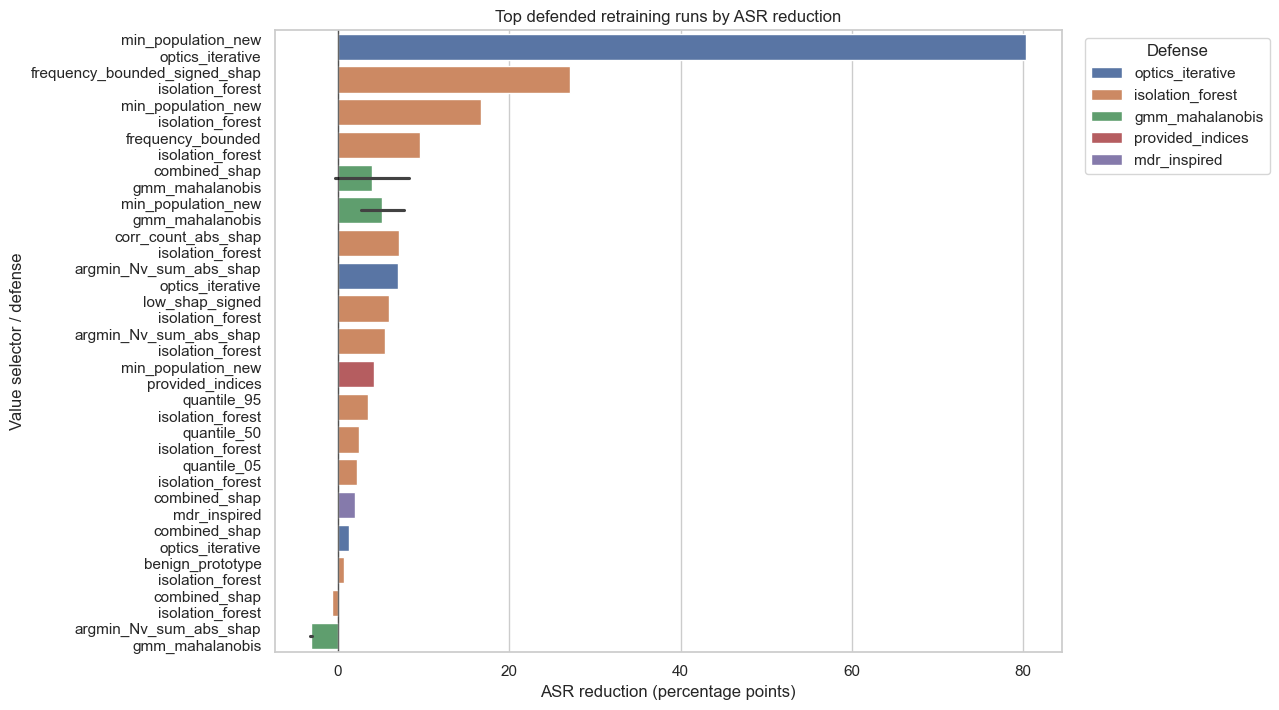

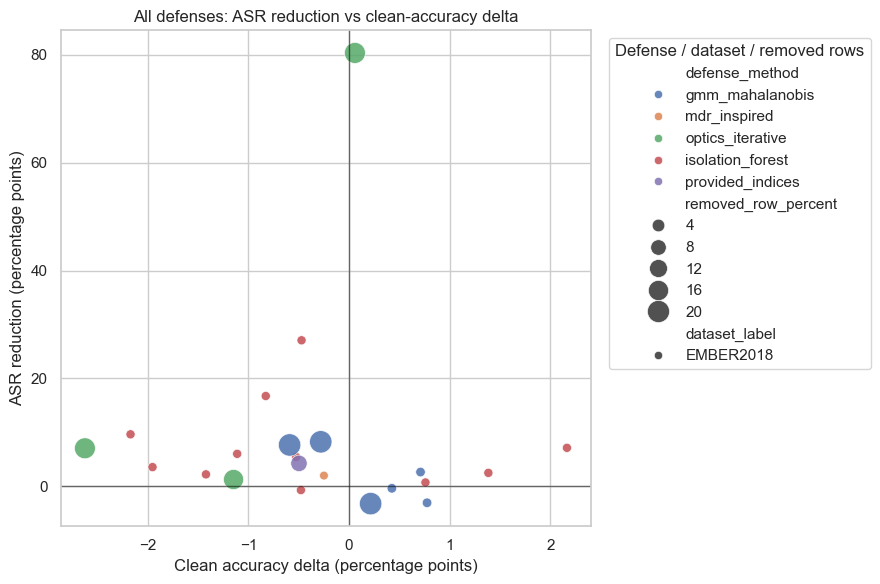

In [8]:
regular_df = defense_df[defense_df["retrain_mode"] == "defended_retrain"].copy()

overview_cols = [
    "dataset_label",
    "sampling_strategy",
    "selector_pair",
    "defense_method",
    "defense_setting",
    "backdoored_asr_percent",
    "defended_asr_percent",
    "asr_reduction_pp",
    "defended_clean_accuracy_percent",
    "clean_accuracy_delta_pp",
    "poison_recall_percent",
    "clean_false_positive_rate_percent",
    "removed_row_percent",
]

display(
    regular_df[overview_cols]
    .sort_values(["dataset_label", "asr_reduction_pp"], ascending=[True, False])
    .round(3)
)

if not regular_df.empty:
    top_plot = regular_df.sort_values("asr_reduction_pp", ascending=False).head(30).copy()
    top_plot["run_label"] = top_plot["value_selector"] + "\n" + top_plot["defense_method"]
    fig, ax = plt.subplots(figsize=(13, max(5, 0.33 * len(top_plot))))
    sns.barplot(
        data=top_plot,
        y="run_label",
        x="asr_reduction_pp",
        hue="defense_method",
        dodge=False,
        ax=ax,
    )
    ax.axvline(0, color="black", linewidth=1, alpha=0.6)
    ax.set_title("Top defended retraining runs by ASR reduction")
    ax.set_xlabel("ASR reduction (percentage points)")
    ax.set_ylabel("Value selector / defense")
    ax.legend(title="Defense", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 6))
    sns.scatterplot(
        data=regular_df,
        x="clean_accuracy_delta_pp",
        y="asr_reduction_pp",
        hue="defense_method",
        style="dataset_label",
        size="removed_row_percent",
        sizes=(40, 260),
        alpha=0.85,
        ax=ax,
    )
    ax.axhline(0, color="black", linewidth=1, alpha=0.5)
    ax.axvline(0, color="black", linewidth=1, alpha=0.5)
    ax.set_title("All defenses: ASR reduction vs clean-accuracy delta")
    ax.set_xlabel("Clean accuracy delta (percentage points)")
    ax.set_ylabel("ASR reduction (percentage points)")
    ax.legend(title="Defense / dataset / removed rows", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## Optional Export

In [9]:
SAVE_TABLES = False

if SAVE_TABLES:
    out_dir = RESULTS_ROOT / "tables"
    out_dir.mkdir(parents=True, exist_ok=True)
    defense_path = out_dir / "defense_metrics_results.csv"
    focus_path = out_dir / "defense_metrics_isolation_forest_focus.csv"
    defense_df.to_csv(defense_path, index=False)
    focus_df.to_csv(focus_path, index=False)
    print("Saved:", defense_path)
    print("Saved:", focus_path)
else:
    print("SAVE_TABLES is False; no files written.")

SAVE_TABLES is False; no files written.
